# Profile plots over Flask Lake 2025

Creates some plots for Kate Winter's AGU 2025 talk.

In [122]:
import os
from coreg import coreg_hillshade
import glob
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import pandas as pd
import rioxarray as rxr


## Load WV DEMs

In [4]:
directory_names = os.listdir('../../../remote sensing/worldview/6158_2025apr22_Kingslake_2024_25_DEMs/dem')
dem_names_lists = [x.split('_')[:-1] for x in directory_names]
dem_names = ['_'.join(x) for x in dem_names_lists][1:]
dem_names = dem_names[1:]
dem_names

['WV01_20250220_102001010B8E9300_102001010C0E9B00_2m',
 'WV01_20240920_102001010360A300_1020010103D16300_2m',
 'WV03_20250125_10400100A1848B00_10400100A1BD5000_2m',
 'WV02_20250102_103001010BAF5D00_103001010C7CFB00_2m']

In [83]:
# glob the metadata file in a directory
aquisition_time = []

for directory_name in directory_names[1:]:

    metadata_file = glob.glob(
        '../../../remote sensing/worldview/6158_2025apr22_Kingslake_2024_25_DEMs/dem/' + directory_name + '/*.txt')
    #open txt file
    #with open(metadata_file[0], 'r') as f:
    lines = open(metadata_file[0], 'r').readlines()


    aquisition_time.append([line.split('=')[1] 
                    for line in lines if 'Image_2_Acquisition_time' in line][0].split('\n')[0])

    # find the acquisition time

aquisition_time = aquisition_time[1:]
print(aquisition_time)

['2025-02-20T16:55:47.603146Z', '2024-09-20T16:52:03.272312Z', '2025-01-25T13:49:54.555175Z', '2025-01-02T12:52:24.694775Z']


## Coregister WV DEMs

In [7]:
ds0 = coreg_hillshade(dem_names[3], dem_names[0]) # script takes two DEMs as arguments. It coregisters the second to the first.
ds1 = coreg_hillshade(dem_names[3], dem_names[1]) # script takes two DEMs as arguments. It coregisters the second to the first.
ds2 = coreg_hillshade(dem_names[3], dem_names[2]) # script takes two DEMs as arguments. It coregisters the second to the first.

gathering file paths and dates
loading dems
eroding bedrock mask
coregistering dem_2 to dem_1
Planimetric Correction Iteration 1
Offset (z,x,y): 0.000, 0.000, 0.000
RMSE = 7.506570816040039
Planimetric Correction Iteration 2
Offset (z,x,y): 0.075, 2.561, 3.482
Translating: 0.08 Z, 2.56 X, 3.48 Y
RMSE = 6.758373737335205
Planimetric Correction Iteration 3
Offset (z,x,y): 0.397, 3.438, 4.305
Translating: 0.40 Z, 3.44 X, 4.30 Y
RMSE = 6.691959381103516
Planimetric Correction Iteration 4
Offset (z,x,y): 0.503, 3.666, 4.472
Translating: 0.50 Z, 3.67 X, 4.47 Y
RMSE = 6.6856865882873535
Planimetric Correction Iteration 5
Offset (z,x,y): 0.532, 3.724, 4.508
Translating: 0.53 Z, 3.72 X, 4.51 Y
RMSE = 6.684952735900879
RMSE step in this iteration (-0.00073) is above threshold (-0.001), stopping and returning values of prior iteration.
Final offset (z,x,y): 0.503, 3.666, 4.472
Final RMSE = 6.6856865882873535
computing elevation change
computing hillshade
gathering file paths and dates
loading dem

In [ ]:
dem0 = ds0.dem_2
dem0 = dem0.assign_coords(time=pd.to_datetime(aquisition_time[0]))
dem1 = ds1.dem_2
dem1 = dem1.assign_coords(time=pd.to_datetime(aquisition_time[1]))
dem2 = ds2.dem_2
dem2 = dem2.assign_coords(time=pd.to_datetime(aquisition_time[2]))
dem3 = ds2.dem_1
dem3 = dem3.assign_coords(time=pd.to_datetime(aquisition_time[3]))
dems = [dem0, dem1, dem2, dem3]

In [57]:
aquisition_time_sorted, dems_sorted = zip(*sorted(
    zip(aquisition_time, dems),
    key=lambda x: x[0]
))

## Define line to extract profile along

In [49]:
import numpy as np
x1 = -2371502.7
x2 =  -2370460.9
y1 = 1225336.2
y2 = 1225124.0
num = 500
xs = np.linspace(x1, x2, num)
ys = np.linspace(y1, y2, num)

## Load UAV DEM

In [ ]:
uav_dem = rxr.open_rasterio('/Users/jkingslake/Documents/projects/current_projects/AntPen_NSF_NERC/remote sensing/uav_imagery/20241208_02_01_ppk_M_DEM.tif')
uav_dem_UPS = uav_dem.rio.reproject("EPSG:3031")

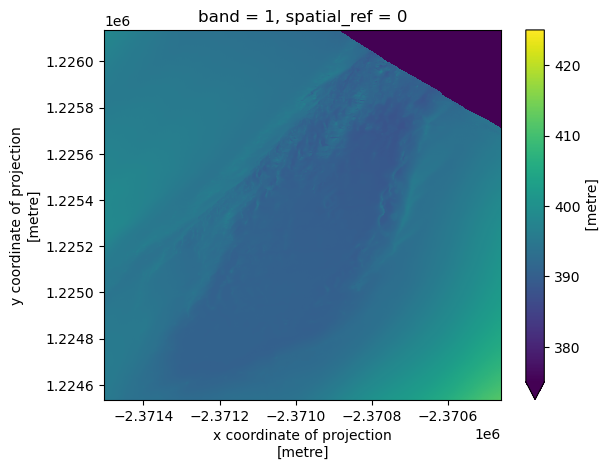

In [143]:
uav_dem_UPS.squeeze().sel(x = slice(x1, x2), y = slice(y1+800, y1-800)).plot.imshow(vmin = 375, vmax = 425)

## plot WV DEMs in order with profile line

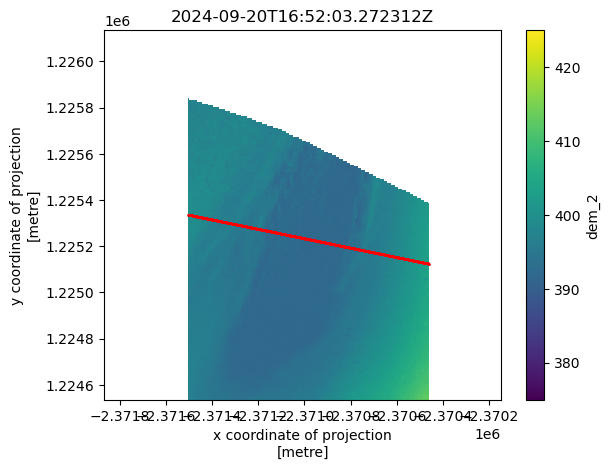

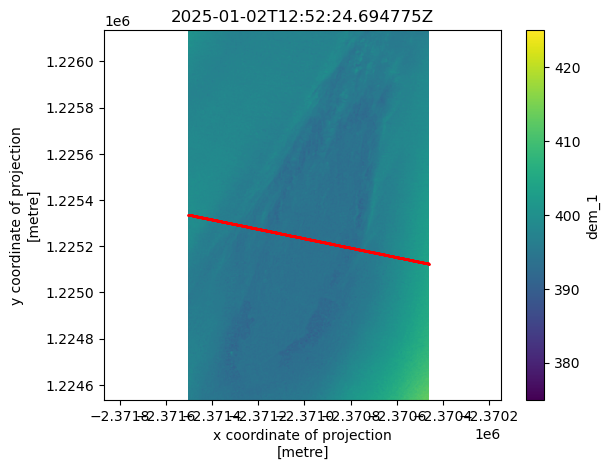

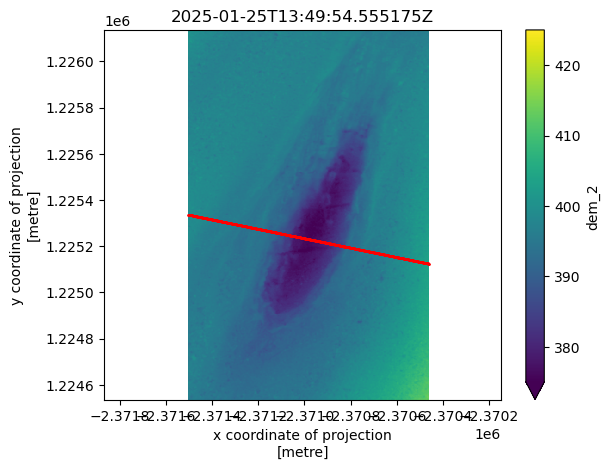

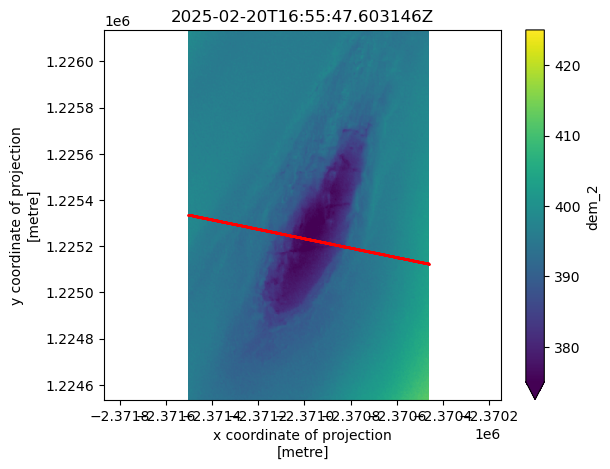

In [61]:
def plot_lake_and_profile(da):
    plt.figure()
    dem.sel(x = slice(x1, x2), y = slice(y1+800, y1-800)).plot.imshow(vmin = 375, vmax = 425)
    plt.axis('equal')
    plt.scatter(xs, ys, color='red', s=1)
    plt.title(dem['time'].item())
    plt.show()
for dem in dems_sorted: plot_lake_and_profile(dem)

## Plot difference map (diff )

difference between 2025-01-25T13:49:54.555175Z and 2025-01-02T12:52:24.694775Z


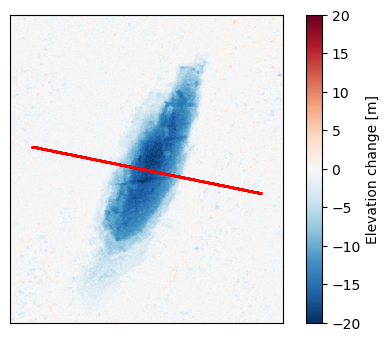

In [160]:
dh = (dems_sorted[2]-dems_sorted[1])
dh.attrs['units'] = 'm'
dh.attrs['long_name'] = 'Elevation change'

fig, ax = plt.subplots(figsize=(6, 4))

dh.sel( x = slice(x1-100, x2+100), y = slice(y1+600, y1-800)).plot.imshow(ax = ax)

plt.scatter(xs, ys, color='red', s=1)
plt.xlim(x1-100, x2+100)
plt.ylim(y1-800, y1+600)
plt.gca().set_aspect('equal', 'box')   # ← force 1:1 aspect ratio
ax.set_title("")         # remove title
ax.set_xticks([])        # no tick marks on x
ax.set_yticks([])
ax.set_xlabel("")       # no x label
ax.set_ylabel("")       # no y label
print(f"difference between {dems_sorted[2]['time'].item()} and {dems_sorted[1]['time'].item()}")

## extract elevation along profiles

In [ ]:
def extract_profile(da, x1, x2, y1, y2):
    import numpy as np
    num = 500
    xs = np.linspace(x1, x2, num)
    ys = np.linspace(y1, y2, num)

    profile = da.interp(x=("points", xs), y=("points", ys))
    profile['distance'] = np.sqrt((profile.x - x1)**2 + (profile.y - y1)**2)    
    profile['distance'].attrs['units'] = 'm'
    profile['distance'].attrs['long_name'] = 'distance along profile'
    return profile

# profile = extract_profile(ds0.dem_2, x1, x2, y1, y2)

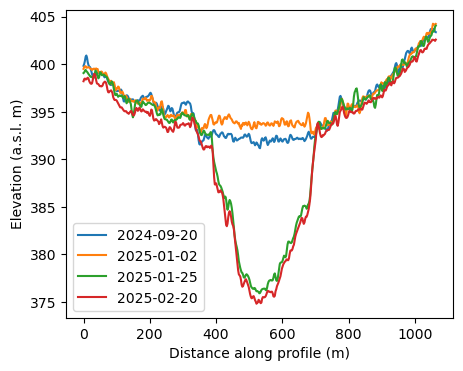

In [149]:
fig, ax = plt.subplots(figsize=(5, 4))
for dem in dems_sorted:
    profile = extract_profile(dem, x1, x2, y1, y2)
    # extract the date in a readable format
    label = pd.to_datetime(dem.time.item()).strftime('%Y-%m-%d')

    ax.plot(profile.distance, profile, label=label)
ax.set_xlabel('Distance along profile (m)')
ax.set_ylabel('Elevation (a.s.l. m)')
ax.legend()
# profile = extract_profile(uav_dem_UPS.squeeze(), x1, x2, y1, y2)
# ax.plot(profile.distance, profile, label='UAV DEM', color='k', linestyle='--')

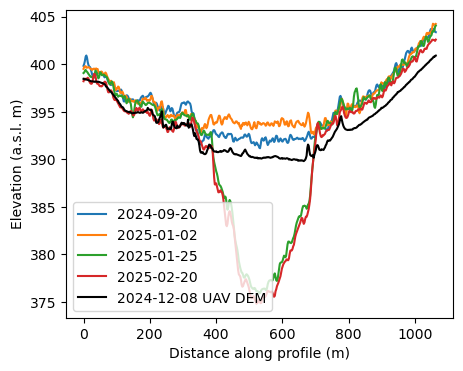

In [155]:
fig, ax = plt.subplots(figsize=(5, 4))
for dem in dems_sorted:
    profile = extract_profile(dem, x1, x2, y1, y2)
    # extract the date in a readable format
    label = pd.to_datetime(dem.time.item()).strftime('%Y-%m-%d')

    ax.plot(profile.distance, profile, label=label)
ax.set_xlabel('Distance along profile (m)')
ax.set_ylabel('Elevation (a.s.l. m)')
ax.legend()

profile = extract_profile(uav_dem_UPS.squeeze(), x1, x2, y1, y2)
ax.plot(profile.distance, profile, label='2024-12-08 UAV DEM', color='k')
ax.set_xlabel('Distance along profile (m)')
ax.set_ylabel('Elevation (a.s.l. m)')
ax.legend()